# 03 · Router frontier and off-policy evaluation

The headline is a frontier, not a single threshold. Every point is evaluated on the same 198-row template-held-out split.

In [1]:
from pathlib import Path
import csv, json, random, statistics, sys
from collections import Counter, defaultdict

ROOT = Path.cwd()
if not (ROOT / "results").exists():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / "scripts"))
from analysis_notebook_utils import *
from IPython.display import SVG, display

def read_csv(path):
    with Path(path).open(encoding="utf-8", newline="") as handle:
        return list(csv.DictReader(handle))

comparison=read_csv(ROOT/'results/evaluator_comparison.csv')
ope=read_csv(ROOT/'results/ope_weight_sensitivity.csv')
benchmark=read_csv(ROOT/'results/benchmark_sensitivity.csv')


Selected policy: Learned epsilon=0.025
Assumed cost savings: 47.6%
Quality delta: +0.0179
95% CI: [-0.0075, +0.0422]
Overlap ESS: 54.2


## Cost–quality frontier

The selected `epsilon = 0.025` point satisfies validation guardrails for direct quality, stabilized doubly robust quality, savings, and overlap.

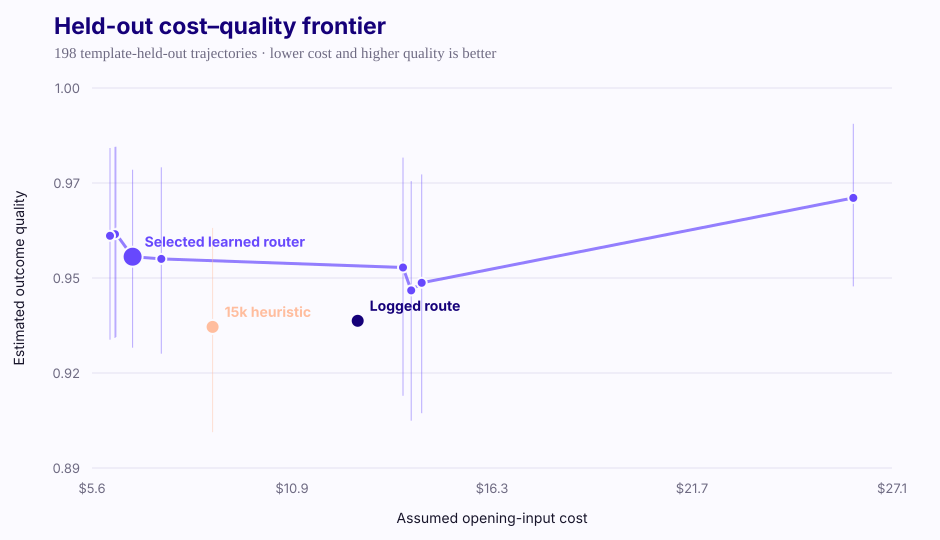

In [2]:
display(SVG(frontier_chart(comparison)))


## Off-policy robustness

The log reveals only one model outcome per trajectory. Stabilized doubly robust estimation corrects the direct quality model on policy/behavior matches. Weight clipping checks whether a few high-propensity corrections dominate.

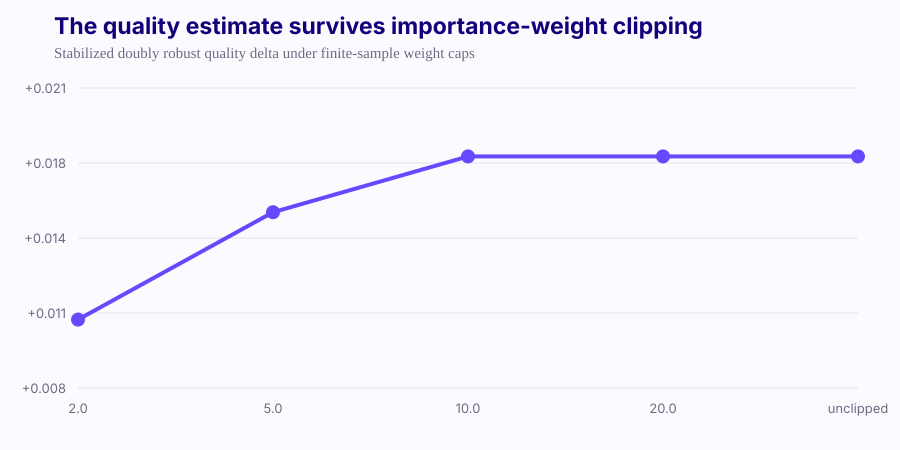

In [3]:
display(SVG(line_chart([r['weight_cap'] for r in ope], [float(r['quality_delta_est']) for r in ope], 'The quality estimate survives importance-weight clipping', 'Stabilized doubly robust quality delta under finite-sample weight caps')))


## Assumption sensitivity

The challenge model IDs are anonymized. Public benchmark and price information is therefore an analogue scenario, not a verified mapping.

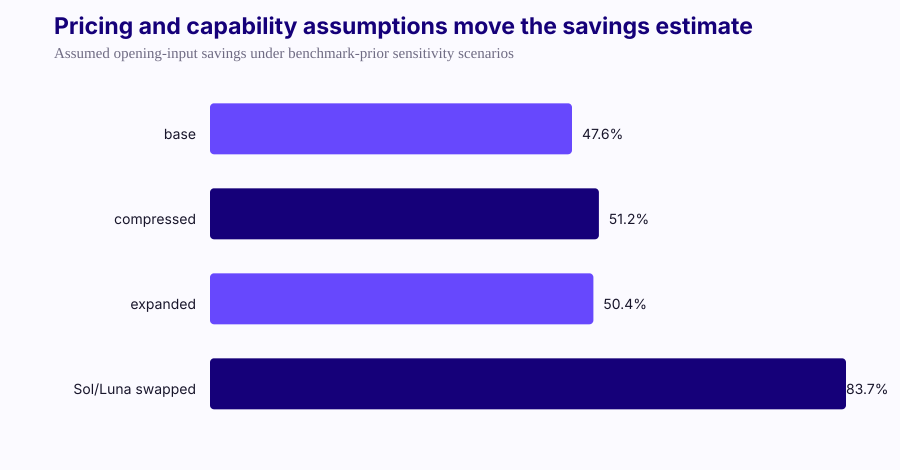

In [4]:
display(SVG(bar_chart([r['scenario'].replace('gpt_sol_luna_swapped','Sol/Luna swapped') for r in benchmark], [100*float(r['cost_savings_pct_est']) for r in benchmark], 'Pricing and capability assumptions move the savings estimate', 'Assumed opening-input savings under benchmark-prior sensitivity scenarios', value_format=lambda v:f'{v:.1f}%')))


### Defensible conclusion

The selected learned router reduces **assumed opening-input cost by 47.6%**, with no detected quality loss. The quality point estimate is `+0.018`, but its 95% interval `[-0.008, +0.042]` crosses zero. The dominant limitation is unobserved counterfactual quality, compounded by missing final responses and an assumed price/model mapping.